### Taking information from t-1 and t0

In [1]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
from sklearn.metrics import average_precision_score                  # type: ignore
import tensorflow as tf                                                                 # type: ignore
from tensorflow.keras.initializers import he_normal # type: ignore
from sklearn.model_selection import train_test_split                                    # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)
from joblib import dump, load                                                           # type: ignore
from tensorflow.keras.models import Sequential                                          # type: ignore
from tensorflow.keras.layers import LSTM, Dense, Dropout                                # type: ignore

2024-07-25 05:46:51.927705: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-07-25 05:46:52.436169: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-07-25 05:46:53.376845: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-25 05:46:55.596588: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


### Importing dataset

In [2]:
test_data_lt1 = pd.read_csv(f"/home/mendrika/mendrika-phd/data/other-location/cleaned/Dakar/t-1-and-t0/test-data-Dakar-lt2-with-t-1.csv", index_col=False)
test_data_lt3 = pd.read_csv(f"/home/mendrika/mendrika-phd/data/other-location/cleaned/Dakar/t-1-and-t0/test-data-Dakar-lt4-with-t-1.csv", index_col=False)
test_data_lt6 = pd.read_csv(f"/home/mendrika/mendrika-phd/data/other-location/cleaned/Dakar/t-1-and-t0/test-data-Dakar-lt7-with-t-1.csv", index_col=False)

In [3]:
test_data_lt1 = test_data_lt1.dropna()
test_data_lt3 = test_data_lt3.dropna()
test_data_lt6 = test_data_lt6.dropna()

In [4]:
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

hour_min = "00"
hour_max = "24"

query = f"{nflics.format(hour_min)} <= `hour`< {nflics.format(hour_max)} and `minute`=={nflics.format('00')}"

test_data_lt1 = test_data_lt1.query(query).reset_index(drop=True)
test_data_lt3 = test_data_lt3.query(query).reset_index(drop=True)
test_data_lt6 = test_data_lt6.query(query).reset_index(drop=True)

### Importing models

#### Dense avec $t_0$

In [5]:
model_lt1_t0_fc = tf.keras.models.load_model(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Dakar-t1.keras")
model_lt3_t0_fc = tf.keras.models.load_model(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Dakar-t3.keras")
model_lt6_t0_fc = tf.keras.models.load_model(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Dakar-t6.keras")

In [6]:
scaler_lt1_t0_fc = scaler_lt3_t0_fc = scaler_lt6_t0_fc =  load(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/Dakar-t1.bin')

#### Dense avec $t_0$ and $t_1$

In [7]:
model_lt1_t0t1_fc = tf.keras.models.load_model("/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/rnn/Dakar-lt1-fc-t0-t-1.keras")
model_lt3_t0t1_fc = tf.keras.models.load_model("/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/rnn/Dakar-lt3-fc-t0-t-1.keras")
model_lt6_t0t1_fc = tf.keras.models.load_model("/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/rnn/Dakar-lt6-fc-t0-t-1.keras")

In [8]:
scaler_lt1_t0t1_fc = load("/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/rnn/Dakar-lt1-fc-t0-t-1.bin")
scaler_lt3_t0t1_fc = load("/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/rnn/Dakar-lt3-fc-t0-t-1.bin")
scaler_lt6_t0t1_fc = load("/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/rnn/Dakar-lt6-fc-t0-t-1.bin")

#### LSTM avec $t_0$ and $t_{-1}$

In [9]:
model_lt1_t0t1_lstm = tf.keras.models.load_model("/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/rnn/Dakar-lt1-lstm-t0-t-1.keras")
model_lt3_t0t1_lstm = tf.keras.models.load_model("/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/rnn/Dakar-lt3-lstm-t0-t-1.keras")
model_lt6_t0t1_lstm = tf.keras.models.load_model("/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/rnn/Dakar-lt6-lstm-t0-t-1.keras")

In [10]:
scaler_lt1_t0t1_lstm = load(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/rnn/Dakar-lt1-lstm-t0-t-1.bin")
scaler_lt3_t0t1_lstm = load(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/rnn/Dakar-lt3-lstm-t0-t-1.bin")
scaler_lt6_t0t1_lstm = load(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/rnn/Dakar-lt6-lstm-t0-t-1.bin")

#### Choosing field to include in the data

In [11]:
y_test_t1 = test_data_lt1["Cb_dakar_t2"].to_numpy()
y_test_t3 = test_data_lt3["Cb_dakar_t4"].to_numpy()
y_test_t6 = test_data_lt6["Cb_dakar_t7"].to_numpy()

In [12]:
t0 = "year,month,day,hour,minute,"
t1 = "year_t1,month_t1,day_t1,hour_t1,minute_t1,"
loc = wp = ds = sz = "" 
loc_t1 = wp_t1 = ds_t1 = sz_t1 = "" 

for i in range(1, 6):
    loc += f"lat{i},lon{i},"
    wp += f"wp{i},"
    ds += f"ds{i},"
    sz += f"size{i},"
    loc_t1 += f"lat{i}_t1,lon{i}_t1,"
    wp_t1 += f"wp{i}_t1,"
    ds_t1 += f"ds{i}_t1,"
    sz_t1 += f"size{i}_t1,"

field_t0t1 = t0 + loc + wp + sz + ds + t1 + loc_t1 + wp_t1 + sz_t1 + ds_t1
field_t0 = t1 + loc_t1 + wp_t1 + sz_t1 + ds_t1

test_data_lt1_t0 = test_data_lt1[field_t0.split(',')[:-1]]
test_data_lt3_t0 = test_data_lt3[field_t0.split(',')[:-1]]
test_data_lt6_t0 = test_data_lt6[field_t0.split(',')[:-1]]

In [13]:
columns={'year_t1':'year', 'month_t1':'month', 'day_t1':'day', 'hour_t1':'hour', 'minute_t1':'minute', 'lat1_t1':'lat1', 'lon1_t1':'lon1', 'lat2_t1':'lat2', 'lon2_t1':'lon2', 'lat3_t1':'lat3', 'lon3_t1':'lon3', 'lat4_t1':'lat4', 'lon4_t1':'lon4', 'lat5_t1':'lat5', 'lon5_t1':'lon5', 'wp1_t1':'wp1', 'wp2_t1':'wp2', 'wp3_t1':'wp3', 'wp4_t1':'wp4', 'wp5_t1':'wp5', 'size1_t1':'size1', 'size2_t1':'size2', 'size3_t1':'size3', 'size4_t1':'size4', 'size5_t1':'size5', 'ds1_t1':'ds1', 'ds2_t1':'ds2', 'ds3_t1':'ds3', 'ds4_t1':'ds4', 'ds5_t1':'ds5'}

In [14]:
test_data_lt1_t0 = test_data_lt1_t0.rename(columns=columns)
test_data_lt3_t0 = test_data_lt3_t0.rename(columns=columns)
test_data_lt6_t0 = test_data_lt6_t0.rename(columns=columns)

In [15]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [16]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [17]:
to_scale_t0 = wp + sz + ds
to_scale_t0t1 = wp + wp_t1 + sz + sz_t1 + ds + ds_t1
t0t1 = t0 + t1

transform = True
if transform:
    test_data_lt1_t0 = log_transform(test_data_lt1_t0, to_scale_t0.split(',')[:-1])    
    test_data_lt1_t0 = sqrt_transform(test_data_lt1_t0, t0.split(',')[:-1])

    test_data_lt3_t0 = log_transform(test_data_lt3_t0, to_scale_t0.split(',')[:-1])    
    test_data_lt3_t0 = sqrt_transform(test_data_lt3_t0, t0.split(',')[:-1])

    test_data_lt6_t0 = log_transform(test_data_lt6_t0, to_scale_t0.split(',')[:-1])    
    test_data_lt6_t0 = sqrt_transform(test_data_lt6_t0, t0.split(',')[:-1])

    test_data_lt1 = log_transform(test_data_lt1, to_scale_t0t1.split(',')[:-1])    
    test_data_lt1 = sqrt_transform(test_data_lt1, t0t1.split(',')[:-1])

    test_data_lt3 = log_transform(test_data_lt3, to_scale_t0t1.split(',')[:-1])    
    test_data_lt3 = sqrt_transform(test_data_lt3, t0t1.split(',')[:-1])

    test_data_lt6 = log_transform(test_data_lt6, to_scale_t0t1.split(',')[:-1])    
    test_data_lt6 = sqrt_transform(test_data_lt6, t0t1.split(',')[:-1])

##### for $t_0$ only

In [18]:
x_test_t1_t0 = test_data_lt1_t0.to_numpy()
x_test_t3_t0 = test_data_lt3_t0.to_numpy()
x_test_t6_t0 = test_data_lt6_t0.to_numpy()

##### for $t_0$ and $t_{-1}$

In [19]:
x_test_t1 = test_data_lt1.drop(["Cb_dakar_t2"], axis=1).to_numpy()
x_test_t3 = test_data_lt3.drop(["Cb_dakar_t4"], axis=1).to_numpy()
x_test_t6 = test_data_lt6.drop(["Cb_dakar_t7"], axis=1).to_numpy()

### Scaling

In [20]:
x_test_t1.shape

(4084, 60)

In [21]:
x_test_t1_fc_std = scaler_lt1_t0t1_fc.transform(x_test_t1)
x_test_t3_fc_std = scaler_lt3_t0t1_fc.transform(x_test_t3)
x_test_t6_fc_std = scaler_lt6_t0t1_fc.transform(x_test_t6)

In [22]:
x_test_t1_lstm_std = scaler_lt1_t0t1_lstm.transform(x_test_t1)
x_test_t3_lstm_std = scaler_lt3_t0t1_lstm.transform(x_test_t3)
x_test_t6_lstm_std = scaler_lt6_t0t1_lstm.transform(x_test_t6)

In [23]:
x_test_t1_lstm_std = x_test_t1_lstm_std.reshape(y_test_t1.shape[0], 2, 30)
x_test_t3_lstm_std = x_test_t3_lstm_std.reshape(y_test_t3.shape[0], 2, 30)
x_test_t6_lstm_std = x_test_t6_lstm_std.reshape(y_test_t6.shape[0], 2, 30)

In [24]:
x_test_t1_t0_fc_std = scaler_lt1_t0_fc.transform(x_test_t1_t0)
x_test_t3_t0_fc_std = scaler_lt3_t0_fc.transform(x_test_t3_t0)
x_test_t6_t0_fc_std = scaler_lt6_t0_fc.transform(x_test_t6_t0)

#### Prediction

In [25]:
def class_prediction(model, x, y):
    y_hat = model.predict(x)      
    bs = brier_score_loss(y, y_hat)    
    auc = roc_auc_score(y, y_hat)
    return y_hat, auc, bs

In [26]:
def cutoff_youdens_j(fpr, tpr, thresholds):
    j_scores = tpr-fpr
    j_ordered = sorted(zip(j_scores, thresholds))
    return j_ordered[-1][1]

In [27]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

In [28]:
y_test_pred_lt1_t0_fc, auc_test_lt1_t0_fc, bs_test_lt1_t0_fc = class_prediction(model_lt1_t0_fc, x_test_t1_t0_fc_std, y_test_t1)
y_test_pred_lt3_t0_fc, auc_test_lt3_t0_fc, bs_test_lt3_t0_fc = class_prediction(model_lt3_t0_fc, x_test_t3_t0_fc_std, y_test_t3)
y_test_pred_lt6_t0_fc, auc_test_lt6_t0_fc, bs_test_lt6_t0_fc = class_prediction(model_lt6_t0_fc, x_test_t6_t0_fc_std, y_test_t6)

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [29]:
y_test_pred_lt1_lstm, auc_test_lt1_lstm, bs_test_lt1_lstm = class_prediction(model_lt1_t0t1_lstm, x_test_t1_lstm_std, y_test_t1)
y_test_pred_lt3_lstm, auc_test_lt3_lstm, bs_test_lt3_lstm = class_prediction(model_lt3_t0t1_lstm, x_test_t3_lstm_std, y_test_t3)
y_test_pred_lt6_lstm, auc_test_lt6_lstm, bs_test_lt6_lstm = class_prediction(model_lt6_t0t1_lstm, x_test_t6_lstm_std, y_test_t6)

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [30]:
y_test_pred_lt1_fc, auc_test_lt1_fc, bs_test_lt1_fc = class_prediction(model_lt1_t0t1_fc, x_test_t1_fc_std, y_test_t1)
y_test_pred_lt3_fc, auc_test_lt3_fc, bs_test_lt3_fc = class_prediction(model_lt3_t0t1_fc, x_test_t3_fc_std, y_test_t3)
y_test_pred_lt6_fc, auc_test_lt6_fc, bs_test_lt6_fc = class_prediction(model_lt6_t0t1_fc, x_test_t6_fc_std, y_test_t6)

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [31]:
prob_pred_t1_t0t1_fc, prob_true_t1_t0t1_fc, no_pred_per_bin_t1_t0t1_fc = reliability_curve(y_test_t1, y_test_pred_lt1_fc.flatten())
prob_pred_t3_t0t1_fc, prob_true_t3_t0t1_fc, no_pred_per_bin_t3_t0t1_fc = reliability_curve(y_test_t3, y_test_pred_lt3_fc.flatten())
prob_pred_t6_t0t1_fc, prob_true_t6_t0t1_fc, no_pred_per_bin_t6_t0t1_fc = reliability_curve(y_test_t6, y_test_pred_lt6_fc.flatten())

In [32]:
prob_pred_t1_t0t1_lstm, prob_true_t1_t0t1_lstm, no_pred_per_bin_t1_t0t1_lstm = reliability_curve(y_test_t1, y_test_pred_lt1_lstm.flatten())
prob_pred_t3_t0t1_lstm, prob_true_t3_t0t1_lstm, no_pred_per_bin_t3_t0t1_lstm = reliability_curve(y_test_t3, y_test_pred_lt3_lstm.flatten())
prob_pred_t6_t0t1_lstm, prob_true_t6_t0t1_lstm, no_pred_per_bin_t6_t0t1_lstm = reliability_curve(y_test_t6, y_test_pred_lt6_lstm.flatten())

In [33]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)  
  plt.plot(100*fp, 100*tp, label=name, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,101])
  plt.ylim([0,101])
  plt.grid(True, linewidth=0.3)
  ax = plt.gca()
  ax.set_aspect('equal')
  plt.tight_layout()

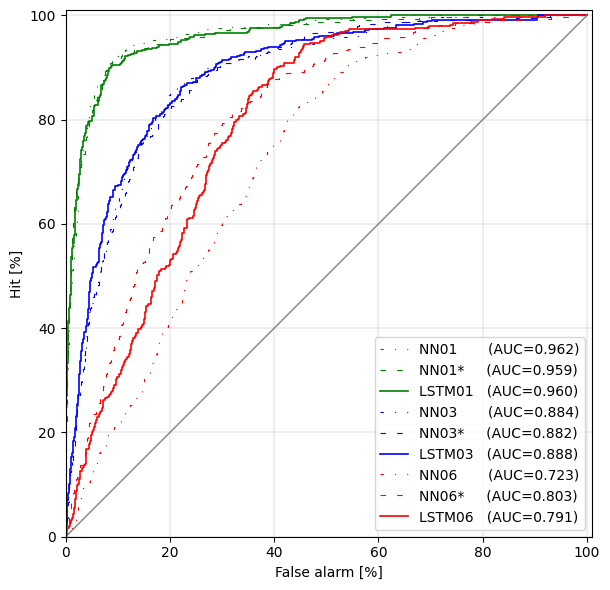

In [42]:
mpl.rcParams['figure.figsize'] = (7,6)

plot_roc(f"NN01       (AUC={auc_test_lt1_t0_fc:.3f})", y_test_t1, y_test_pred_lt1_t0_fc, color="green", linestyle=(0, (3, 10, 1, 10, 1, 10)), linewidth=0.8)
plot_roc(f"NN01*     (AUC={auc_test_lt1_fc:.3f})", y_test_t1, y_test_pred_lt1_fc, color="green", linestyle=(0, (5, 10)), linewidth=0.8)
plot_roc(f"LSTM01   (AUC={auc_test_lt1_lstm:.3f})", y_test_t1, y_test_pred_lt1_lstm, color="green", linestyle="-", linewidth=1.2)


plot_roc(f"NN03       (AUC={auc_test_lt3_t0_fc:.3f})", y_test_t3, y_test_pred_lt3_t0_fc, color="blue", linestyle=(0, (3, 10, 1, 10, 1, 10)), linewidth=0.8)
plot_roc(f"NN03*     (AUC={auc_test_lt3_fc:.3f})", y_test_t3, y_test_pred_lt3_fc, color="blue", linestyle=(0, (5, 10)), linewidth=0.8)
plot_roc(f"LSTM03   (AUC={auc_test_lt3_lstm:.3f})", y_test_t3, y_test_pred_lt3_lstm, color="blue", linestyle="-", linewidth=1.2)


plot_roc(f"NN06       (AUC={auc_test_lt6_t0_fc:.3f})", y_test_t6, y_test_pred_lt6_t0_fc, color="red", linestyle=(0, (3, 10, 1, 10, 1, 10)), linewidth=0.8)
plot_roc(f"NN06*     (AUC={auc_test_lt6_fc:.3f})", y_test_t6, y_test_pred_lt6_fc, color="red", linestyle=(0, (5, 10)), linewidth=0.8)
plot_roc(f"LSTM06   (AUC={auc_test_lt6_lstm:.3f})", y_test_t6, y_test_pred_lt6_lstm, color="red", linestyle="-", linewidth=1.2)

plt.plot(np.arange(0,1.2,0.2)*100, np.arange(0,1.2,0.2)*100, color="gray", linewidth=1)

plt.legend(loc='lower right');

In [35]:
bs_t1_ref = bs_test_lt1_t0_fc
bs_t3_ref = bs_test_lt3_t0_fc
bs_t6_ref = bs_test_lt6_t0_fc

In [36]:
bss_t1_fc = 1 - bs_test_lt1_fc / bs_test_lt1_t0_fc
bss_t1_lstm = 1 - bs_test_lt1_lstm / bs_test_lt1_t0_fc

In [37]:
bss_t3_fc = 1 - bs_test_lt3_fc / bs_test_lt3_t0_fc
bss_t3_lstm = 1 - bs_test_lt3_lstm / bs_test_lt3_t0_fc

In [38]:
bss_t6_fc = 1 - bs_test_lt6_fc / bs_test_lt6_t0_fc
bss_t6_lstm = 1 - bs_test_lt6_lstm / bs_test_lt6_t0_fc

In [39]:
print(bss_t1_fc, bss_t1_lstm)

-0.011700214246550988 -0.06423809396166114


In [40]:
print(bss_t3_fc, bss_t3_lstm)

0.0308937689899782 0.08004621928809996


In [41]:
print(bss_t6_fc, bss_t6_lstm)

0.09282559300119797 0.08043262962834774
